In [1]:
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint

# Кейс

Команде автоклассифайда нужно найти прокси-метрику, хорошо коррелированную с покупкой авто искателем.

# Исходные данные

- user_id id пользователя;

- views суммарное количество просмотров объявлений за весь период активности в классифайде на момент ухода искателя в отток;

- contacts суммарное количество контактов по объявлениям (просмотры телефона и написанные сообщения) за весь период активности в классифайде на момент ухода в отток;

- last_7_views просмотры за 7 дней до ухода в отток;

- last_3_views просмотры за 3 дня до ухода в отток;

- last_7_contacts контакты за 7 дней до ухода в отток;

- last_3_contacts контакты за 3 дня до ухода в отток;

- live_days длительность в днях с первого момента появления в продукте до ухода в отток;

- messages_events количество написанных сообщений искателем;

- add_to_favor_events количество добавленных объявлений в избранное;

- max_views_delta разница между самым малоактивным в просмотрах днем (но не нулевым) и самым активным днем в просмотрах.

# Загрузка данных

In [3]:
data = pd.read_csv('proxy_metrics.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              1193 non-null   int64  
 1   views                1193 non-null   int64  
 2   contacts             1193 non-null   int64  
 3   last_7_views         1193 non-null   int64  
 4   last_3_views         1193 non-null   int64  
 5   last_7_contacts      1193 non-null   int64  
 6   last_3_contacts      1193 non-null   int64  
 7   live_days            1193 non-null   int64  
 8   messages_events      1193 non-null   int64  
 9   max_views_delta      1193 non-null   int64  
 10  add_to_favor_events  1193 non-null   float64
 11  is_bought            1193 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 112.0 KB


In [12]:
data.head(10)

,user_id,views,contacts,last_7_views,last_3_views,last_7_contacts,last_3_contacts,live_days,messages_events,max_views_delta,add_to_favor_events,is_bought
0,151042503,84,2,84,39,2,2,8,0,6,0.0,0
1,151212422,95,0,95,36,0,0,8,0,7,0.0,0
2,151206815,118,3,118,40,3,2,8,0,2,0.0,0
3,151284254,11,0,11,2,0,0,7,0,8,0.0,0
4,151088604,48,2,48,8,2,0,8,0,1,0.0,0
5,150999609,82,0,82,8,0,0,8,0,3,0.0,0
6,151004829,358,8,358,139,8,3,8,0,8,0.0,0
7,151080266,62,0,62,17,0,0,8,0,3,0.0,0
8,151075531,61,3,61,19,3,0,8,0,1,0.0,0
9,151276320,148,1,148,25,1,0,8,0,4,0.0,0


# Описательный анализ данных

In [17]:
# средняя конверсия в покупку авто для пользователей
conversion_rate = data["is_bought"].mean()
print(f"Средняя конверсия в покупку: {conversion_rate:.2}")

Средняя конверсия в покупку: 0.34


In [19]:
#среднее количество контактов за весь период у тех, кто не купил авто
mean_contacts_not_bought = data.loc[data["is_bought"] == 0, "contacts"].mean()
print(f"Среднее количество контактов у некупивших авто: {mean_contacts_not_bought:.2f}")

Среднее количество контактов у некупивших авто: 12.98


In [21]:
#во сколько раз среднее количество добавлений в избранное (add_to_favor_events) 
#отличается для каждой из двух когорт (тех, кто купил авто и тех, кто не купил авто)
mean_fav_bought = data.loc[data["is_bought"] == 1, "add_to_favor_events"].mean()
mean_fav_not_bought = data.loc[data["is_bought"] == 0, "add_to_favor_events"].mean()

ratio = mean_fav_bought / mean_fav_not_bought if mean_fav_not_bought != 0 else float("inf")

print(f"Среднее добавлений в избранное (купившие): {mean_fav_bought:.2f}")
print(f"Среднее добавлений в избранное (не купившие): {mean_fav_not_bought:.2f}")
print(f"Во сколько раз отличаются значения: {ratio:.2f} раз")

Среднее добавлений в избранное (купившие): 0.32
Среднее добавлений в избранное (не купившие): 0.16
Во сколько раз отличаются значения: 2.03 раз


In [23]:
# Доля пользователей без контактов среди купивших авто
no_contacts_bought = (data.loc[(data["is_bought"] == 1) & (data["contacts"] == 0)].shape[0] /
                      data.loc[data["is_bought"] == 1].shape[0])

# Доля пользователей без контактов среди не купивших авто
no_contacts_not_bought = (data.loc[(data["is_bought"] == 0) & (data["contacts"] == 0)].shape[0] /
                          data.loc[data["is_bought"] == 0].shape[0])

print(f"Доля пользователей без контактов (купившие авто): {no_contacts_bought:.2}")
print(f"Доля пользователей без контактов (не купившие авто): {no_contacts_not_bought:.2}")


Доля пользователей без контактов (купившие авто): 0.037
Доля пользователей без контактов (не купившие авто): 0.1


In [25]:
# Средний LT (длительность от первого дня до ухода в отток) для купивших авто
mean_lt_bought = data.loc[data["is_bought"] == 1, "live_days"].mean()

# Средний LT для не купивших авто
mean_lt_not_bought = data.loc[data["is_bought"] == 0, "live_days"].mean()

print(f"Средний LT (купившие авто): {mean_lt_bought:.2f} дней")
print(f"Средний LT (не купившие авто): {mean_lt_not_bought:.2f} дней")


Средний LT (купившие авто): 10.22 дней
Средний LT (не купившие авто): 12.72 дней


In [27]:
# Избегаем деления на 0, заменяя нулевые контакты на 1
data["views_to_contacts"] = data["contacts"] / data["views"].replace(0, 1)

# Среднее отношение контактов к просмотрам для купивших авто
mean_ratio_bought = data.loc[data["is_bought"] == 1, "views_to_contacts"].mean()

# Среднее отношение контактов к просмотрам для не купивших авто
mean_ratio_not_bought = data.loc[data["is_bought"] == 0, "views_to_contacts"].mean()

print(f"Среднее отношение контактов к просмотрам (купившие авто): {mean_ratio_bought:.2f}")
print(f"Среднее отношение контактов к просмотрам (не купившие авто): {mean_ratio_not_bought:.2f}")


Среднее отношение контактов к просмотрам (купившие авто): 0.03
Среднее отношение контактов к просмотрам (не купившие авто): 0.02


 # Поиск корреляции

In [30]:
# Функция, которая проверяет наличие корреляции
# между категориальной и количественной переменной

def find_cat_quant_correlation(quant_value, binary_mask, plot = True, print_inference = True):
    '''
    quant_value - количественная переменная,  для которой считаем корреляцию
    binary_mask - бинарная переменная (True, False), для которой считаем корреляцию
    plot - надо ли отрисовывать график
    print_inference - надо ли принтовать выводы и основные метркии
    '''

    # разбиваем количественную метрику на группы по тому, была ли целевая конверсия или нет
    group_1 = quant_value[binary_mask] # binary = 1
    group_2 = quant_value[~binary_mask] # binary = 0

    # считаем pointbiserial корреляцию, тест Краскелла-Уолесса и обычный Т-тест
    pointbiserialr = ss.pointbiserialr(quant_value, binary_mask)[0]
    kruskal_pval = ss.kruskal(group_1, group_2)[1]
    ttest_pval = ss.ttest_ind(group_1, group_2)[1]

    # принтуем выводы
    if print_inference:
        print('Mean quant value for group (binary=1) =', group_1.mean())
        print('Mean quant value for group (binary=0) =', group_2.mean())

        print('Median quant value for group (binary=1) =', group_1.median())
        print('Median quant value for group (binary=0) =', group_2.median())

        print('Kruskal-Wallis H Test p-value =', kruskal_pval)
        print('T-test p-value =', ttest_pval)
        print('point biserial correlation =', pointbiserialr)

    # рисуем график распределения для двух групп, чтобы проиллюстрировать различия в группах
    if plot:
        plt.figure(figsize=(16,6))
        sns.kdeplot(group_1, color = 'red', label = 'Binary = True')
        sns.kdeplot(group_2, color = 'blue', label = 'Binary = False')
        plt.axvline(x = group_1.mean(), linestyle = '--', color = 'red')
        plt.axvline(x = group_2.mean(), linestyle = '--', color = 'blue')
        plt.legend()

    return({'point biserial R':pointbiserialr,
            'kruskal_pval':kruskal_pval,
            'ttest_pval':ttest_pval})

In [32]:
# Функция для визуализации и поиска оптимальных порогов для создания прокси-метрики

def proxy_metrics_bins_analizer(quant_value, binary_mask, step):

    #разбиваем исходную количественную величину на квантили с нужным шагом
    deciles_bins = np.quantile(quant_value, np.arange(0, 1, step))
    #разбиваем ряд на бины
    inds = np.digitize(quant_value, deciles_bins, right = False)
    # агрегируем
    df = pd.DataFrame({'quant_value':quant_value,
                  'binary': binary_mask,
                  'bins': inds})
    inference = df.groupby('bins').mean()

    #считаем point biserial корреляцию
    point_biserial_R = find_cat_quant_correlation(quant_value = quant_value, binary_mask=binary_mask, plot = False, print_inference = False)['point biserial R']

    # рисуем график
    plt.figure(figsize=(12,6))
    sns.lineplot(y = inference['quant_value'], x = inference.index*step, color = 'red', label = 'quant_value')
    plt.axhline(y = quant_value.median(), linestyle = '--', color = 'red')
    plt.text(x = inds.mean()*step, y = np.quantile(quant_value, 0.95), s ='point_biserial_R = {}'.format(point_biserial_R), )
    ax2 = plt.twinx()
    sns.lineplot(y = inference['binary'], x = inference.index*step, color = 'blue', ax=ax2, label = 'binary share')
    plt.axhline(y = binary_mask.mean(), linestyle = '--', color = 'blue')
    plt.legend()

## Рассмотрим метрику Просмотры

Посмотрим, есть ли различия в распределении просмотров в зависимости от того, купили ли авто или нет

Mean quant value for group (binary=1) = 1021.3300492610838
Mean quant value for group (binary=0) = 730.4294790343075
Median quant value for group (binary=1) = 503.0
Median quant value for group (binary=0) = 368.0
Kruskal-Wallis H Test p-value = 5.3065061016086465e-05
T-test p-value = 0.0001480470649402244
point biserial correlation = 0.10963715907458792


{'point biserial R': 0.10963715907458792,
 'kruskal_pval': 5.3065061016086465e-05,
 'ttest_pval': 0.0001480470649402244}

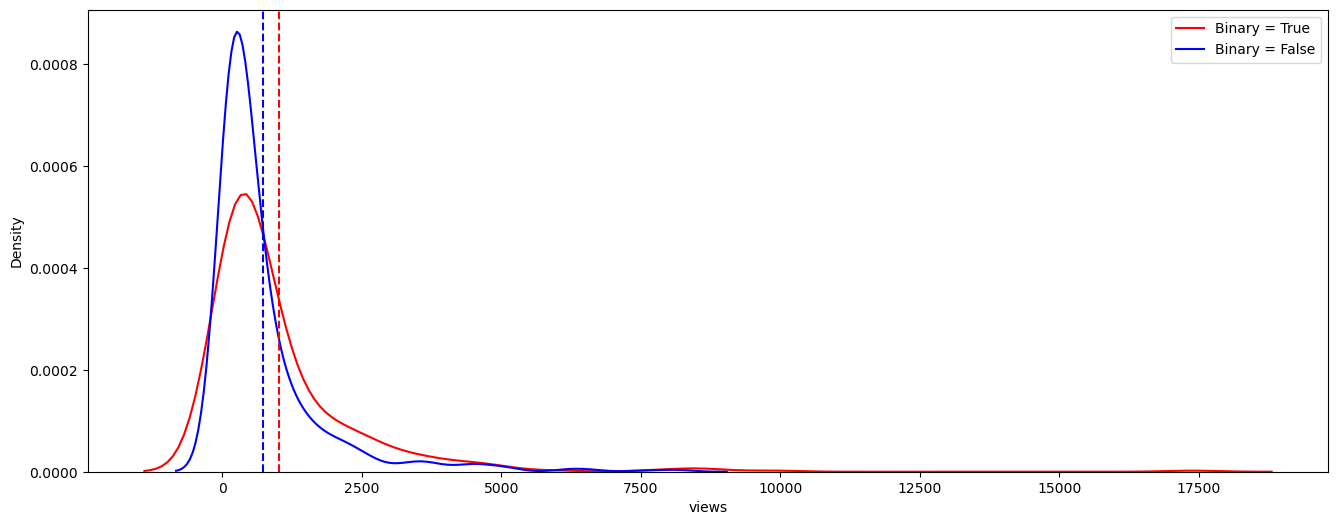

In [15]:
find_cat_quant_correlation(quant_value = data['views'], binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

Видим, что распределения и средние явно различаются (стат критерии показывают различия в средних), но корреляция недостаточно высокая

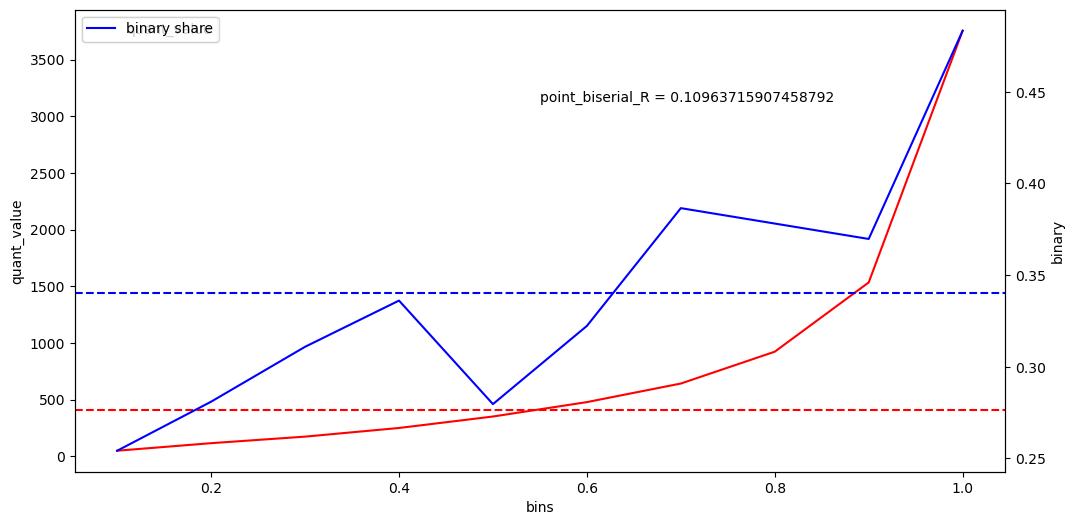

In [27]:
proxy_metrics_bins_analizer(quant_value = data['views'], binary_mask=data['is_bought']== 1, step = 0.1)

Видно, что просмотры отлавливают влияние на рост вероятности продать авто. Но видно, что есть много других факторов, размывающих влияние. Попробуем поискать еще хорошие варианты метрик

## Рассмотрим метрику Суммарные контакты

Mean quant value for group (binary=1) = 24.32512315270936
Mean quant value for group (binary=0) = 12.978398983481576
Median quant value for group (binary=1) = 12.0
Median quant value for group (binary=0) = 6.0
Kruskal-Wallis H Test p-value = 5.543069998568082e-19
T-test p-value = 4.33809546483678e-12
point biserial correlation = 0.19871891825759605


{'point biserial R': 0.19871891825759605,
 'kruskal_pval': 5.543069998568082e-19,
 'ttest_pval': 4.33809546483678e-12}

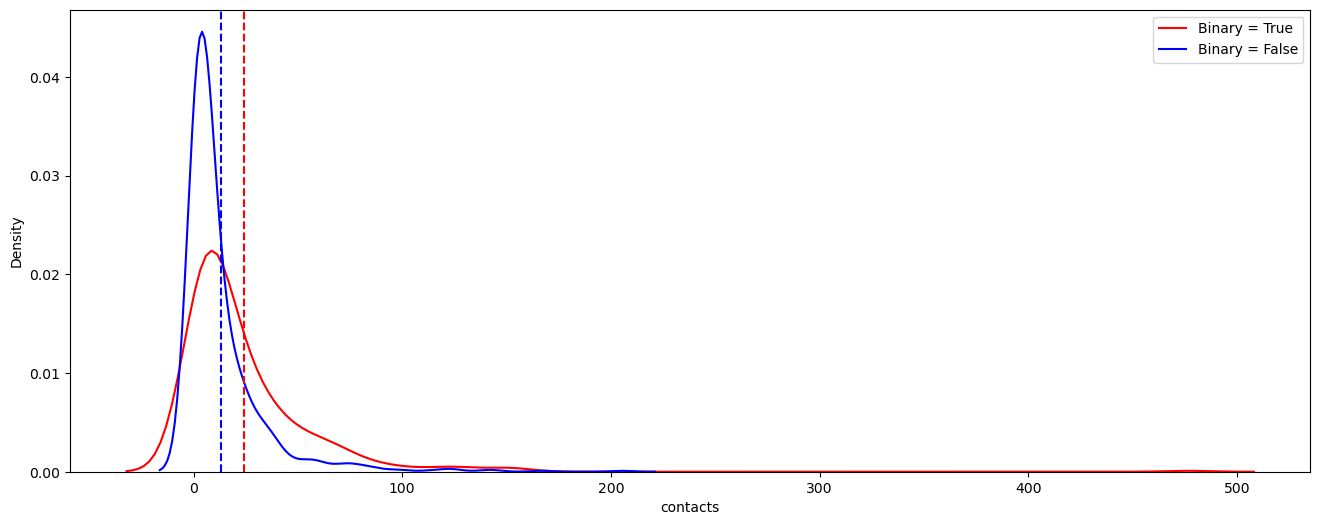

In [31]:
find_cat_quant_correlation(quant_value = data['contacts'], binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

Мера различий между группами (p-value в критериях) выглядит более значимой. Так же, как и уровень корреляции. Значит, мы двигаемся в правильном направлении.

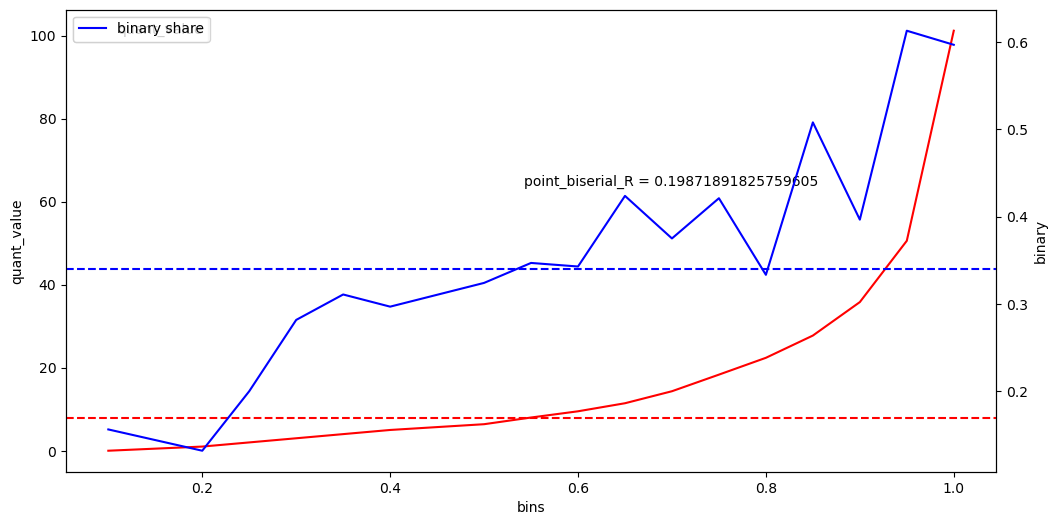

In [35]:
proxy_metrics_bins_analizer(quant_value = data['contacts'], binary_mask=data['is_bought']== 1, step = 0.05)

Видно, что между контактами и долей купленных автомобилей есть корреляция

### Преобразуем метрику контактов

Mean quant value for group (binary=1) = 2.621626730765931
Mean quant value for group (binary=0) = 1.9647865738535728
Median quant value for group (binary=1) = 2.5649493574615367
Median quant value for group (binary=0) = 1.9459101490553132
Kruskal-Wallis H Test p-value = 5.543069998568082e-19
T-test p-value = 6.240407228686518e-20
point biserial correlation = 0.2603217975063434


{'point biserial R': 0.2603217975063434,
 'kruskal_pval': 5.543069998568082e-19,
 'ttest_pval': 6.240407228686518e-20}

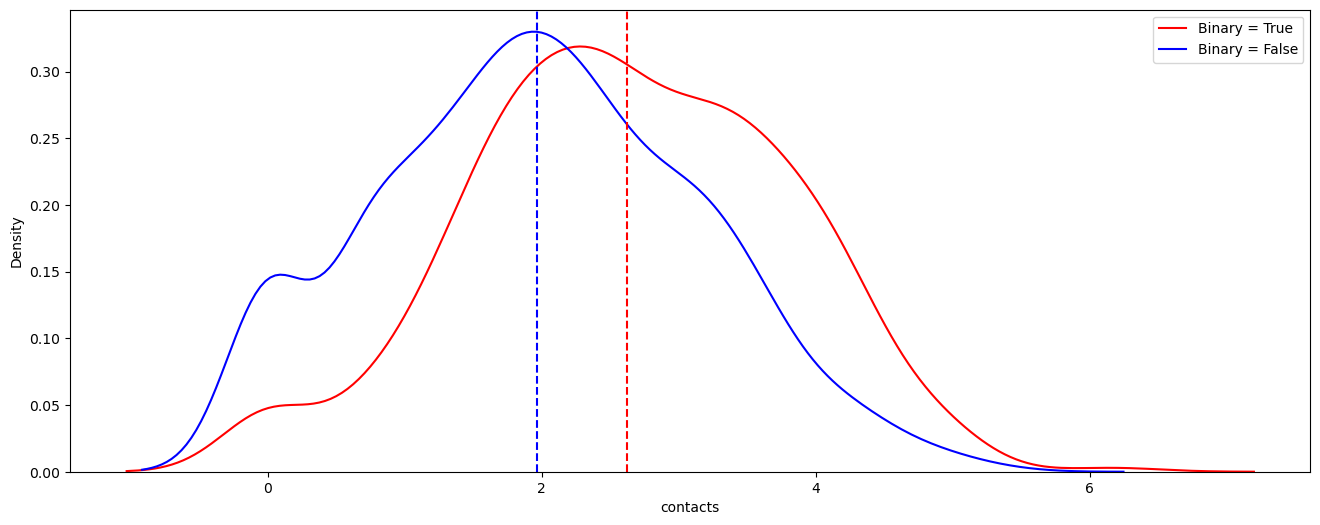

In [39]:
find_cat_quant_correlation(quant_value = np.log(data['contacts']+1), binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

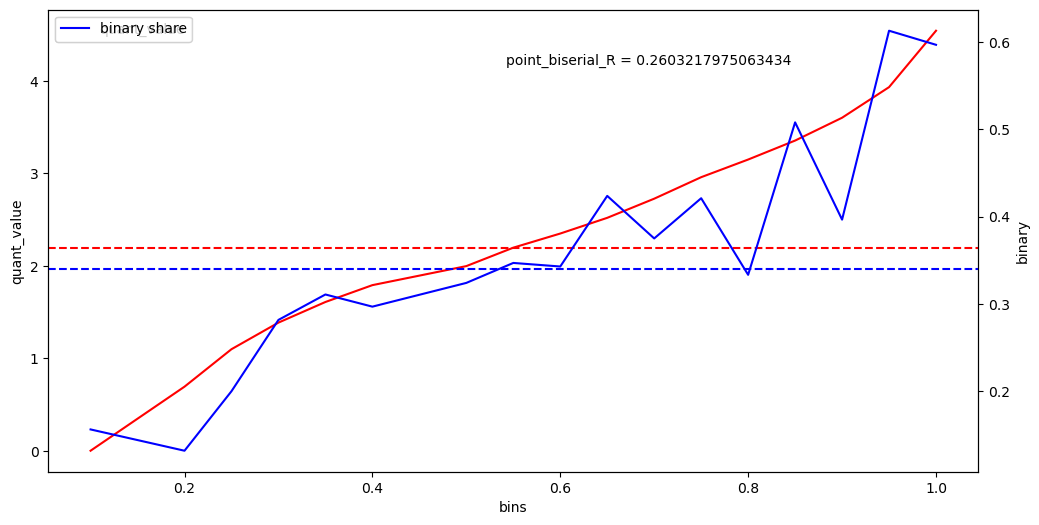

In [40]:
proxy_metrics_bins_analizer(quant_value = np.log(data['contacts']+1), binary_mask=data['is_bought']== 1, step = 0.05)

После преобразования метрики контактов корреляция стала видна еще сильнее. Тот факт, что логарифм работает на корреляцию лучше, говорит о том, что вероятность сконтактировать прирастает нелинейно от количества контактов.

## Рассмотрим метрику live days

Mean quant value for group (binary=1) = 10.219211822660098
Mean quant value for group (binary=0) = 12.72299872935197
Median quant value for group (binary=1) = 8.0
Median quant value for group (binary=0) = 8.0
Kruskal-Wallis H Test p-value = 4.349845742932125e-14
T-test p-value = 1.5187583714796581e-05
point biserial correlation = -0.12488555151409073


{'point biserial R': -0.12488555151409073,
 'kruskal_pval': 4.349845742932125e-14,
 'ttest_pval': 1.5187583714796581e-05}

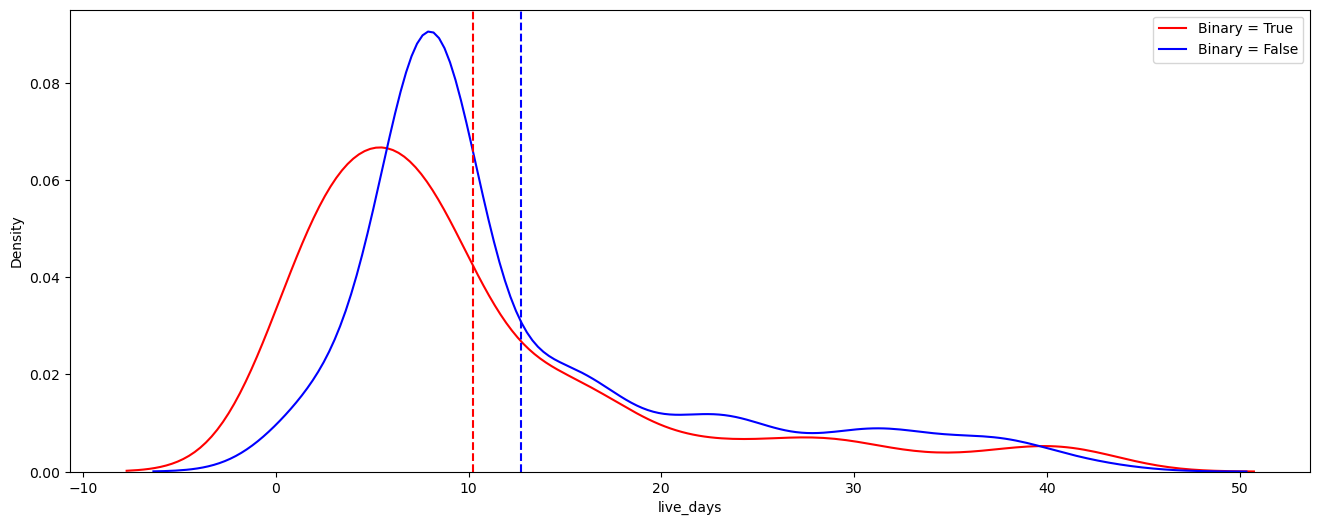

In [45]:
find_cat_quant_correlation(quant_value = (data['live_days']), binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

Видно, что длительность пребывания в live влияет на вероятность купить автомобиль. При этом вероятность падает с ростом длительности присутствия в live. Также кажется, что влияние длительности нелинейное, поэтому попробуем преобразовать метрику.

### Преобразуем метрику live days

Mean quant value for group (binary=1) = 1.9116519471903581
Mean quant value for group (binary=0) = 2.3028244699408007
Median quant value for group (binary=1) = 2.0794415416798357
Median quant value for group (binary=0) = 2.0794415416798357
Kruskal-Wallis H Test p-value = 4.349845742932125e-14
T-test p-value = 3.0860852847094263e-15
point biserial correlation = -0.22564124391151352


{'point biserial R': -0.22564124391151352,
 'kruskal_pval': 4.349845742932125e-14,
 'ttest_pval': 3.0860852847094263e-15}

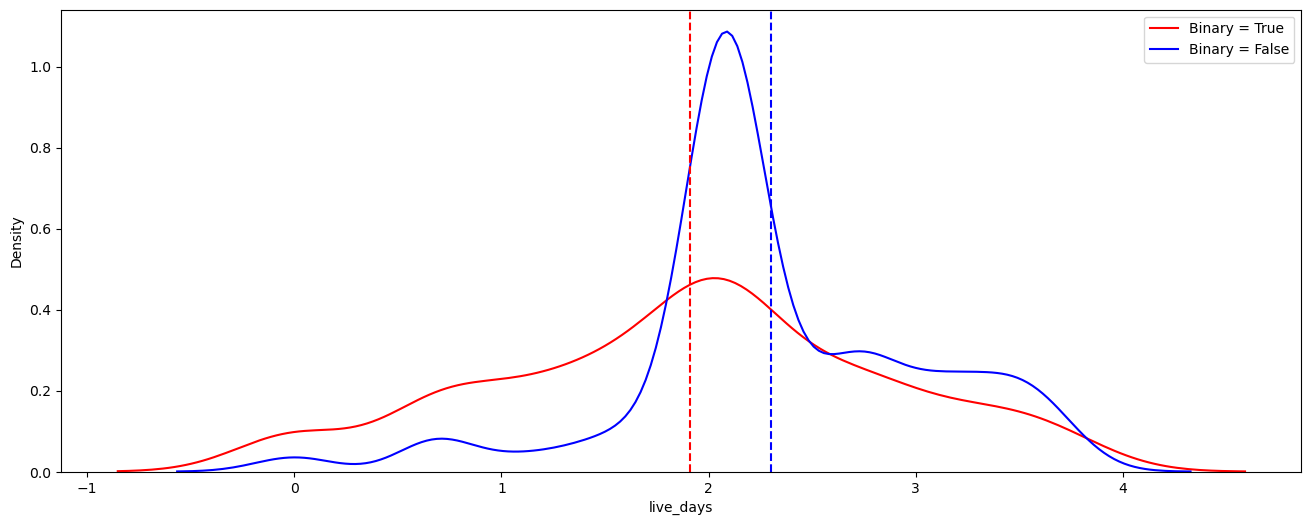

In [48]:
find_cat_quant_correlation(quant_value = np.log(data['live_days']), binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

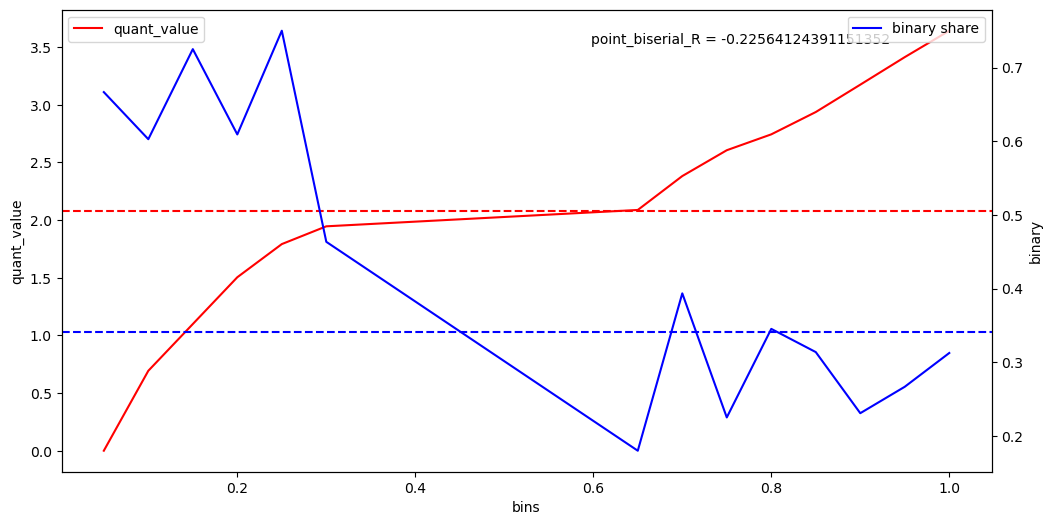

In [50]:
proxy_metrics_bins_analizer( np.log(data['live_days']), binary_mask=data['is_bought']== 1, step = 0.05)

Видим, что метрика длительности пребывания в live важная для определения вероятности совершения покупки. Но сама по себе все еще несет не достаточно сильную корреляцию.

## Рассмотрим метрику контакты за последние несколько дней перед уходом в архив

### 7 дней

Mean quant value for group (binary=1) = 16.165024630541872
Mean quant value for group (binary=0) = 7.031766200762389
Median quant value for group (binary=1) = 10.0
Median quant value for group (binary=0) = 4.0
Kruskal-Wallis H Test p-value = 2.187389457336492e-29
T-test p-value = 1.0543457006044373e-23
point biserial correlation = 0.28483383958689656


{'point biserial R': 0.28483383958689656,
 'kruskal_pval': 2.187389457336492e-29,
 'ttest_pval': 1.0543457006044373e-23}

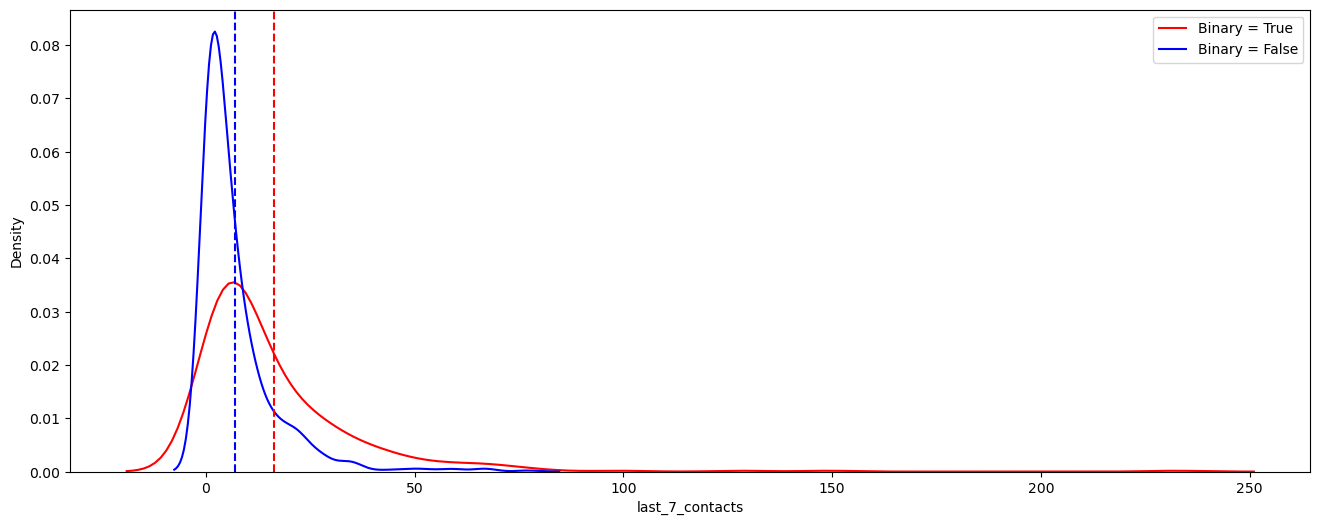

In [55]:
find_cat_quant_correlation(quant_value = data['last_7_contacts'], binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

#### попробуем логарифмировать

Mean quant value for group (binary=1) = 2.324007522475958
Mean quant value for group (binary=0) = 1.558640441513432
Median quant value for group (binary=1) = 2.3978952727983707
Median quant value for group (binary=0) = 1.6094379124341003
Kruskal-Wallis H Test p-value = 2.187389457336492e-29
T-test p-value = 9.635689356892867e-32
point biserial correlation = 0.3302061154355892


{'point biserial R': 0.3302061154355892,
 'kruskal_pval': 2.187389457336492e-29,
 'ttest_pval': 9.635689356892867e-32}

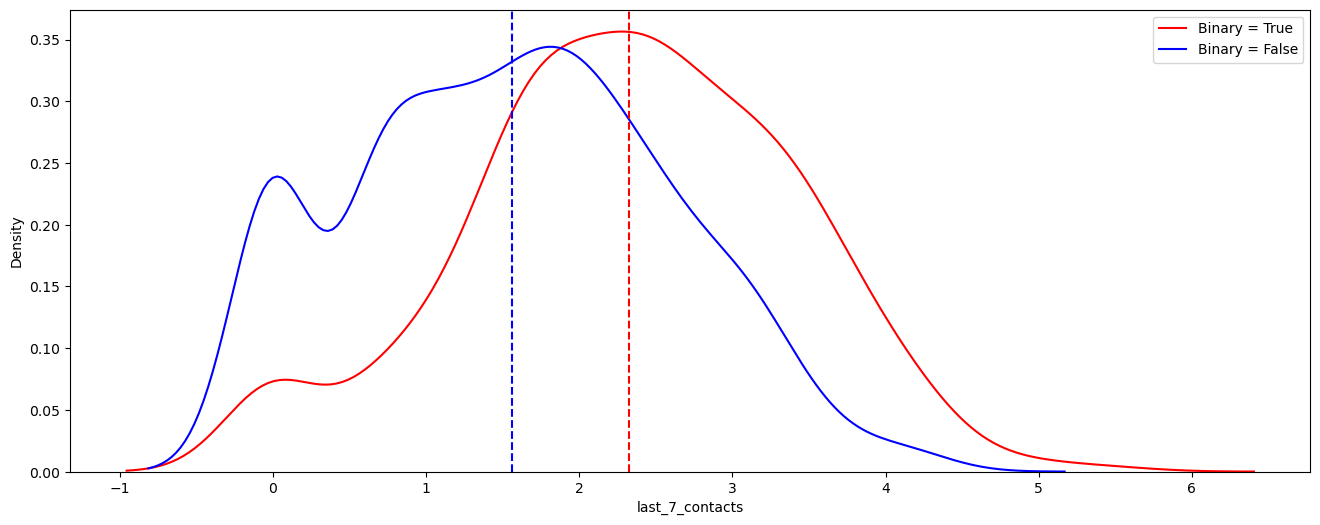

In [58]:
find_cat_quant_correlation(quant_value = np.log(data['last_7_contacts']+1), binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

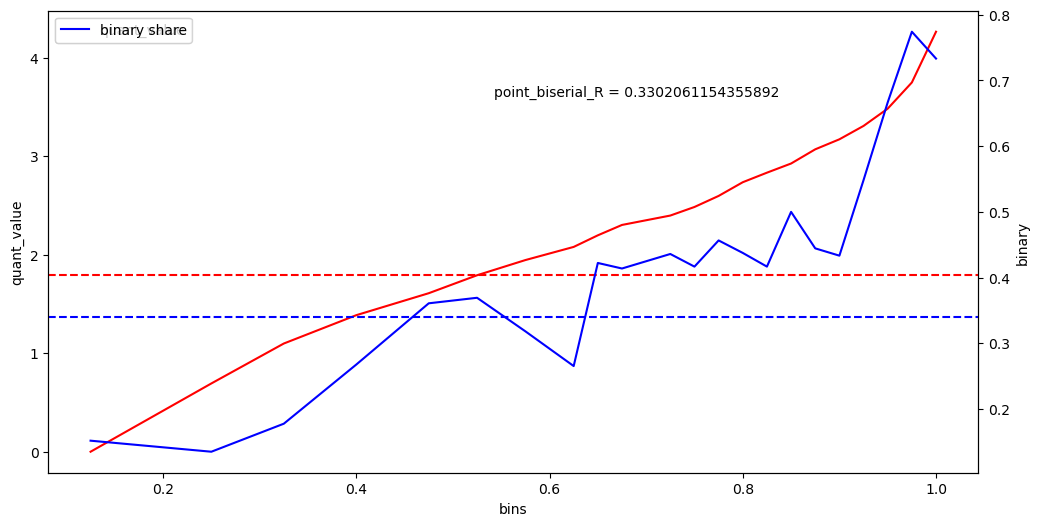

In [60]:
proxy_metrics_bins_analizer(quant_value = np.log(data['last_7_contacts']+1), binary_mask=data['is_bought']== 1, step = 0.025)

### 3 дня

Mean quant value for group (binary=1) = 1.8951297997757153
Mean quant value for group (binary=0) = 0.9424162291583609
Median quant value for group (binary=1) = 1.9459101490553132
Median quant value for group (binary=0) = 0.6931471805599453
Kruskal-Wallis H Test p-value = 2.2215577772866467e-45
T-test p-value = 6.846453497217277e-52
point biserial correlation = 0.4189125444689098


{'point biserial R': 0.4189125444689098,
 'kruskal_pval': 2.2215577772866467e-45,
 'ttest_pval': 6.846453497217277e-52}

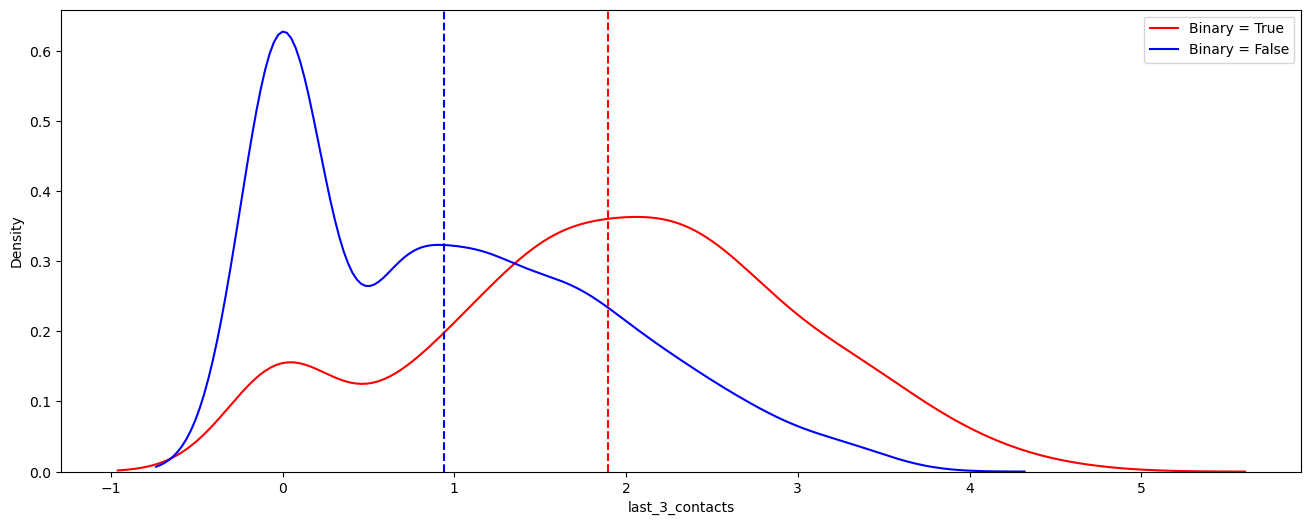

In [63]:
find_cat_quant_correlation(quant_value = np.log(data['last_3_contacts']+1), binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

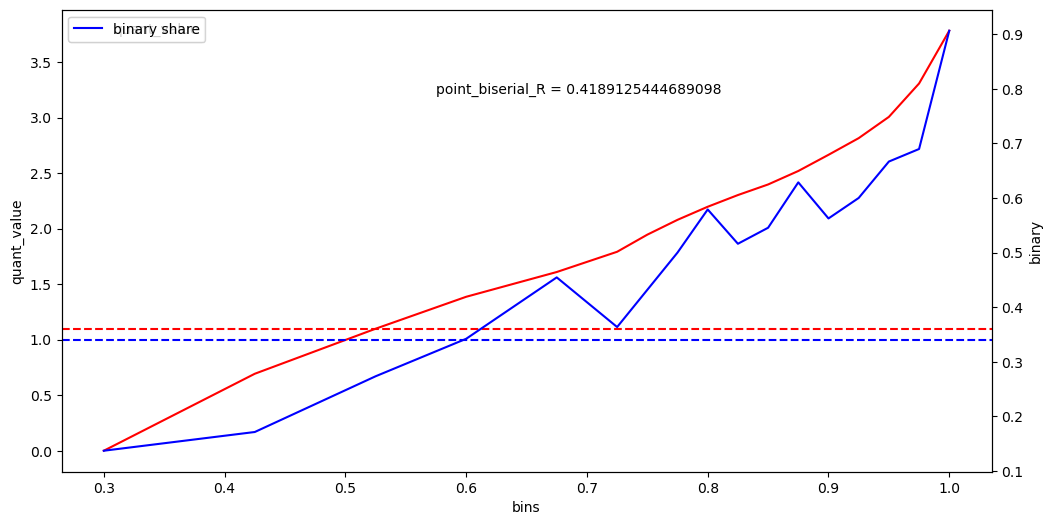

In [64]:
proxy_metrics_bins_analizer(quant_value = np.log(data['last_3_contacts']+1), binary_mask=data['is_bought']== 1, step = 0.025)

Мы нашли неплохого кандидата на роль прокси-метрики для факта покупки авто

## Проверим просмотры за последние несколько дней

### 7 дней

Mean quant value for group (binary=1) = 581.0812807881773
Mean quant value for group (binary=0) = 349.2045743329098
Median quant value for group (binary=1) = 364.5
Median quant value for group (binary=0) = 223.0
Kruskal-Wallis H Test p-value = 8.991523769954602e-13
T-test p-value = 3.811776107097933e-13
point biserial correlation = 0.2081632938478567


{'point biserial R': 0.2081632938478567,
 'kruskal_pval': 8.991523769954602e-13,
 'ttest_pval': 3.811776107097933e-13}

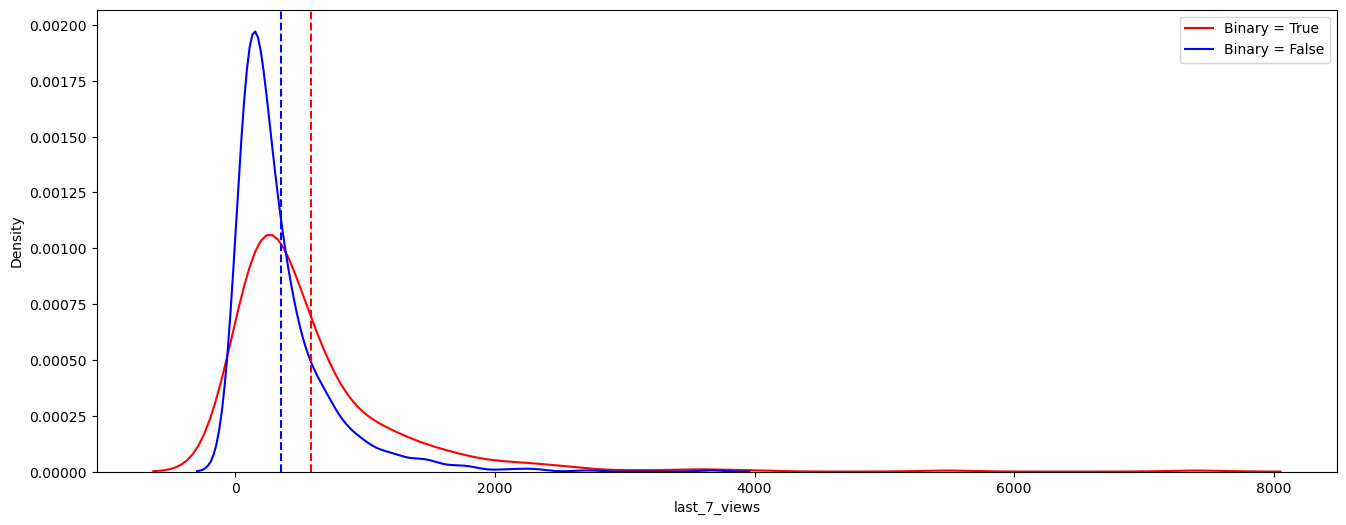

In [70]:
find_cat_quant_correlation(quant_value = data['last_7_views'], binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

### 3 дня

Mean quant value for group (binary=1) = 335.90147783251234
Mean quant value for group (binary=0) = 138.25031766200763
Median quant value for group (binary=1) = 196.0
Median quant value for group (binary=0) = 73.0
Kruskal-Wallis H Test p-value = 1.7667452180529188e-35
T-test p-value = 3.2314661168462165e-28
point biserial correlation = 0.3112803930747103


{'point biserial R': 0.3112803930747103,
 'kruskal_pval': 1.7667452180529188e-35,
 'ttest_pval': 3.2314661168462165e-28}

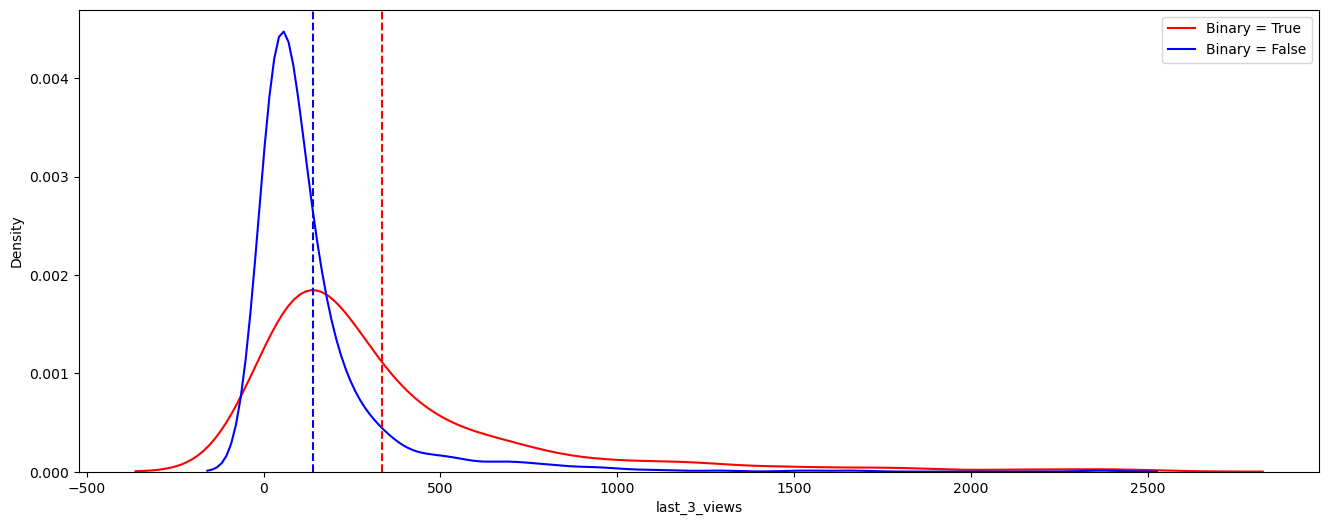

In [73]:
find_cat_quant_correlation(quant_value = data['last_3_views'], binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

#### Прологарифмируем

Mean quant value for group (binary=1) = 5.220161031670055
Mean quant value for group (binary=0) = 4.294882044350205
Median quant value for group (binary=1) = 5.283190844962526
Median quant value for group (binary=0) = 4.30406509320417
Kruskal-Wallis H Test p-value = 1.7667452180529188e-35
T-test p-value = 4.4951974177508544e-36
point biserial correlation = 0.35176836778116516


{'point biserial R': 0.35176836778116516,
 'kruskal_pval': 1.7667452180529188e-35,
 'ttest_pval': 4.4951974177508544e-36}

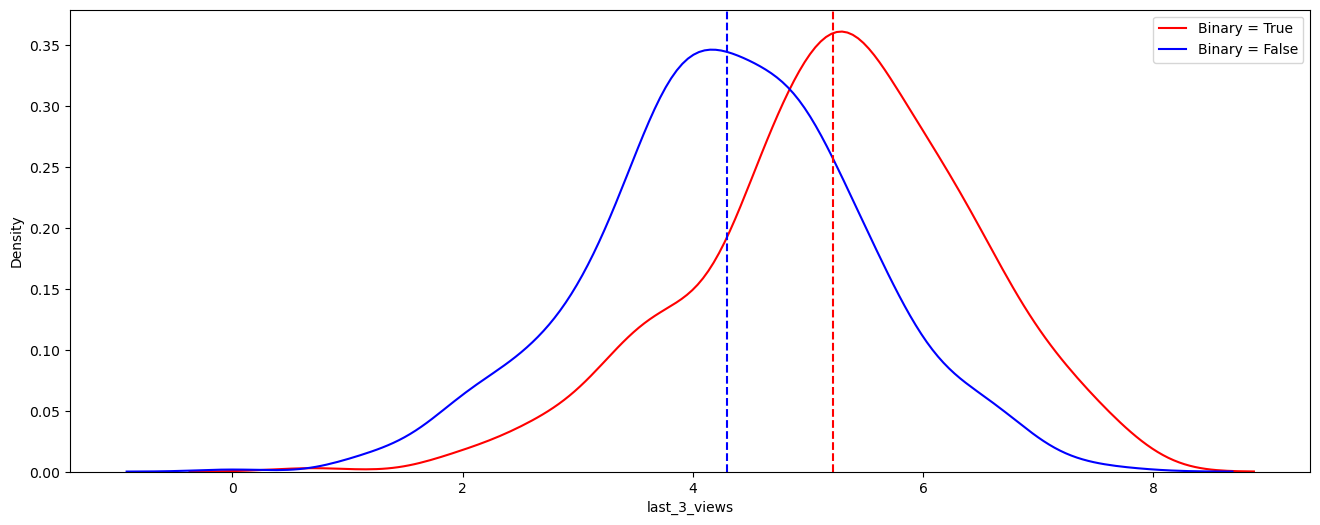

In [76]:
find_cat_quant_correlation(quant_value = np.log(data['last_3_views']+1), binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

Неплохо, эту метрику тоже можно взять в работу

## Проверим оставшиеся метрики

Mean quant value for group (binary=1) = 0.3226600985221675
Mean quant value for group (binary=0) = 0.1588310038119441
Median quant value for group (binary=1) = 0.0
Median quant value for group (binary=0) = 0.0
Kruskal-Wallis H Test p-value = 3.566563459009145e-18
T-test p-value = 0.02786382139290139
point biserial correlation = 0.06367349881474368


{'point biserial R': 0.06367349881474368,
 'kruskal_pval': 3.566563459009145e-18,
 'ttest_pval': 0.02786382139290139}

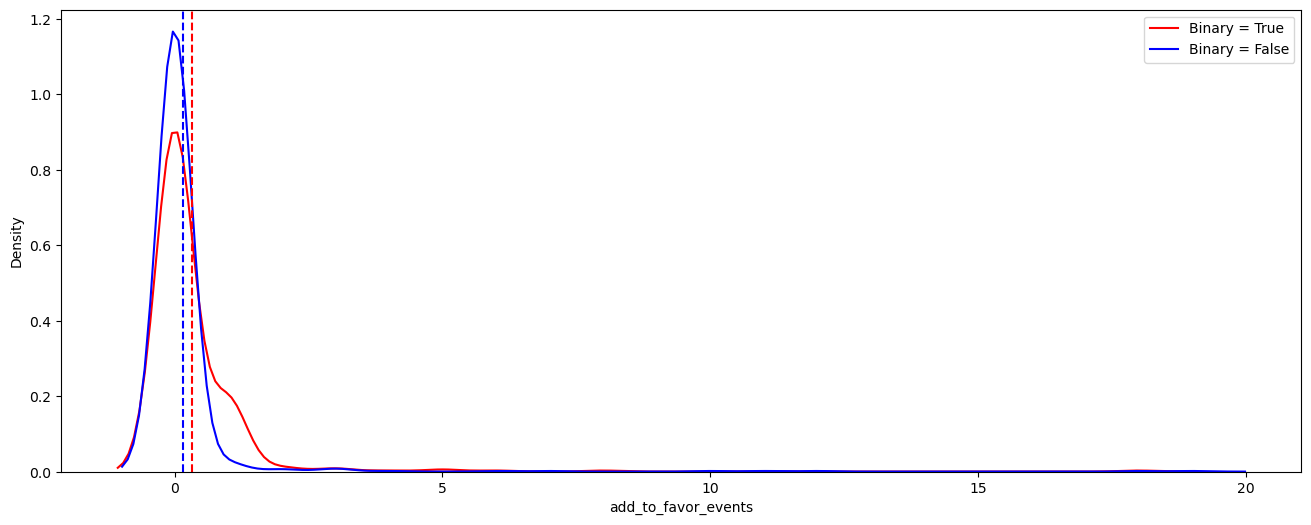

In [80]:
find_cat_quant_correlation(quant_value = data['add_to_favor_events'], binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

Mean quant value for group (binary=1) = 16.11822660098522
Mean quant value for group (binary=0) = 12.32528589580686
Median quant value for group (binary=1) = 9.0
Median quant value for group (binary=0) = 6.0
Kruskal-Wallis H Test p-value = 1.4664586956297273e-06
T-test p-value = 0.002846538036740835
point biserial correlation = 0.08631764000149171


{'point biserial R': 0.08631764000149171,
 'kruskal_pval': 1.4664586956297273e-06,
 'ttest_pval': 0.002846538036740835}

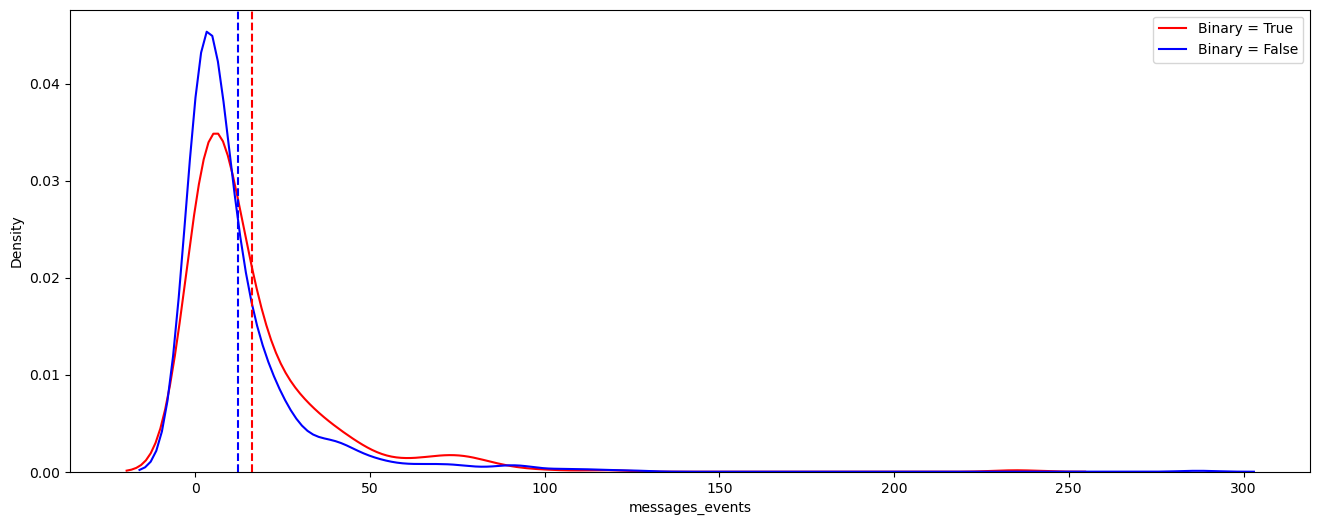

In [82]:
find_cat_quant_correlation(quant_value = data['messages_events'], binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

Mean quant value for group (binary=1) = 36.0935960591133
Mean quant value for group (binary=0) = 16.330368487928844
Median quant value for group (binary=1) = 2.0
Median quant value for group (binary=0) = 4.0
Kruskal-Wallis H Test p-value = 0.9310519802607864
T-test p-value = 2.4347159280315665e-08
point biserial correlation = 0.1606100526092476


{'point biserial R': 0.1606100526092476,
 'kruskal_pval': 0.9310519802607864,
 'ttest_pval': 2.4347159280315665e-08}

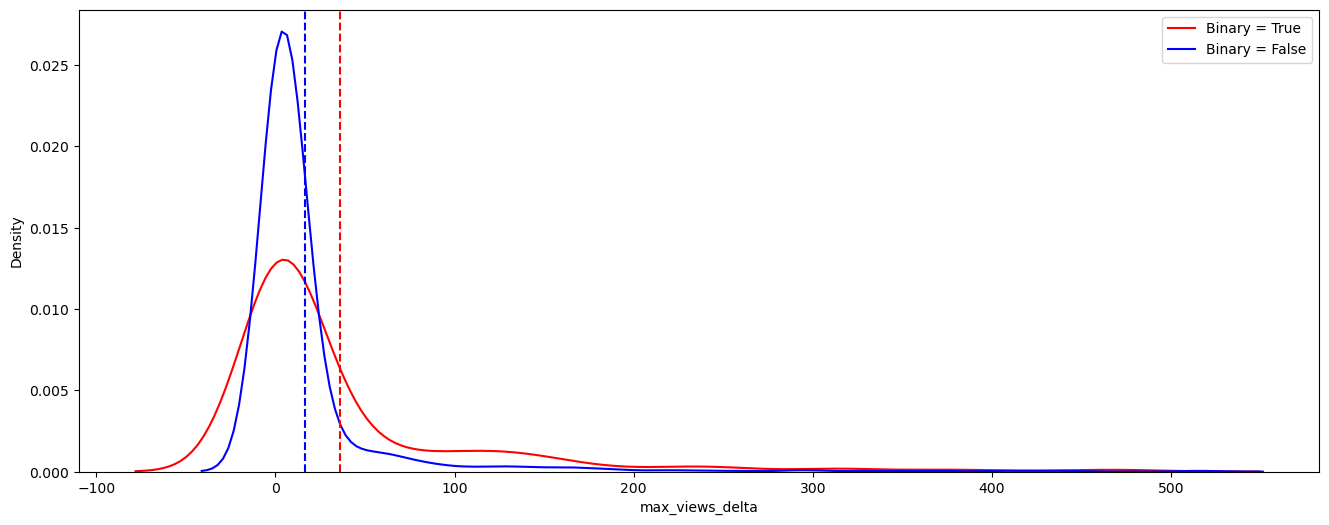

In [84]:
find_cat_quant_correlation(quant_value = data['max_views_delta'], binary_mask=data['is_bought']== 1, plot = True, print_inference = True)

Значения корреляции слишком низкие

## Перебирем пороги для максимизации корреляции между двумя бинарными метриками

### last_3_contacts

In [88]:
# доля бесконтактных
(data['last_3_contacts']== 0).sum() / len(data)

0.2933780385582565

In [51]:
# Функция для оценки ассоциации двух бинарных переменных
def cramers_v(confusion_matrix):
    """ calculate Cramers V statistic for categorial-categorial association.
        uses correction from Bergsma and Wicher,
        Journal of the Korean Statistical Society 42 (2013): 323-328
    """
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    return (cramers_v)

In [92]:
#рассмотрим корреляцию между следующими метриками
confusion_matrix = pd.crosstab(data['is_bought']== 1, data['last_3_contacts']>4)
cramers_v(confusion_matrix.values)

0.34376210152695735

In [94]:
#попробуем найти порог, при котором коэффициент ассоциации cramer V будет максимальным

def max_cramerv_corr_finder(quant_value, binary_mask, plot = True, print_inference = True, step = 1):
    '''
    quant_value - исходная количественная переменная по которой мы пытаемся найти порог
    binary_mask - бинарная метрика с целевой конверсией к которой мы исщем максимальную корреляцию
    plot - нужно ли рисовать граиф
    print_inference - нужно ли принтовать выводы
    step - размер шага с которым мы идем по quant_value и определяем пороги
    '''
    # определяем вектор исходной количественной переменной, на котором мы будет искать максимальную корреляцию
    arange = np.arange(min(quant_value), max(quant_value), step)
    cramers_v_list = []

    #циклом проходим по всем порогам и находим значение cramers_v
    for i in arange:
        confusion_matrix = pd.crosstab(binary_mask, quant_value>i)
        cramers_v_i = cramers_v(confusion_matrix.values)
        cramers_v_list.append(cramers_v_i)

    # сохраняем максимальные найденные значения корреляции и порога, при котором она достигается
    max_corr_quant_value = arange[np.argmax(np.array(cramers_v_list))]
    max_cramer_v = max(cramers_v_list)

    # отрисовываем график
    if plot:
        sns.lineplot(x = arange, y = cramers_v_list)
        plt.axhline(y = np.array(cramers_v_list).max(), linestyle = '--', color = 'red')
        plt.axvline(x = max_corr_quant_value, linestyle = '--', color = 'red')
        plt.xlabel('quant values')
        plt.ylabel('Cramer-V')

    ## принтуем выводы
    if print_inference:
        print('Maximum Cramer V =', np.array(cramers_v_list).max())
        print('Maximum Cramer V quant value = ', max_corr_quant_value)

    return({'max_cramer_v': max_cramer_v,
           'max_corr_quant_value': max_corr_quant_value})

Maximum Cramer V = 0.3672697346990414
Maximum Cramer V quant value =  3


{'max_cramer_v': 0.3672697346990414, 'max_corr_quant_value': 3}

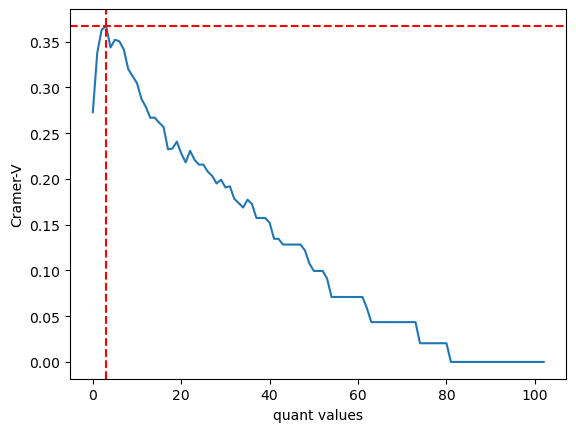

In [96]:
max_cramerv_corr_finder(data['last_3_contacts'], data['is_bought']== 1, plot = True, print_inference = True, step = 1)

Maximum Cramer V = 0.3672697346990414
Maximum Cramer V quant value =  1.4000000000000001


{'max_cramer_v': 0.3672697346990414,
 'max_corr_quant_value': 1.4000000000000001}

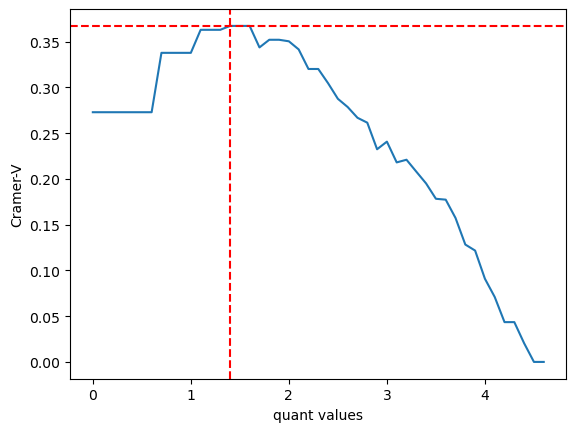

In [98]:
#прологарифмируем
max_cramerv_corr_finder(np.log(data['last_3_contacts']+1), data['is_bought']== 1, plot = True, print_inference = True, step = 0.1)

In [100]:
# преобразуем в исходную шкалу полученное рекомендованное значение
np.exp(1.4)-1

3.0551999668446745

Итак, мы нашли, что по историческим данным наилучшая корреляция достигается при 3+ уровне контактов за 3 дня перед отправкой в архив

### last_3_views

In [103]:
#рассмотрим корреляцию между следующими метриками
confusion_matrix = pd.crosstab(data['is_bought']== 1, data['last_3_views']>4)
cramers_v(confusion_matrix.values)

0.04938413866325172

Maximum Cramer V = 0.3486475362928702
Maximum Cramer V quant value =  151


{'max_cramer_v': 0.3486475362928702, 'max_corr_quant_value': 151}

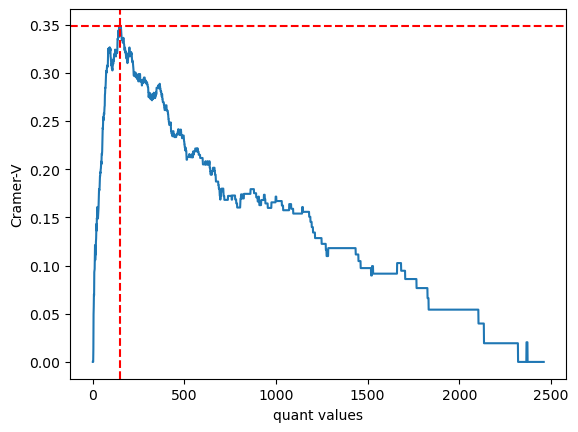

In [105]:
max_cramerv_corr_finder(data['last_3_views'], data['is_bought']== 1, plot = True, print_inference = True, step = 1)

Maximum Cramer V = 0.34454948458130596
Maximum Cramer V quant value =  5.0


{'max_cramer_v': 0.34454948458130596, 'max_corr_quant_value': 5.0}

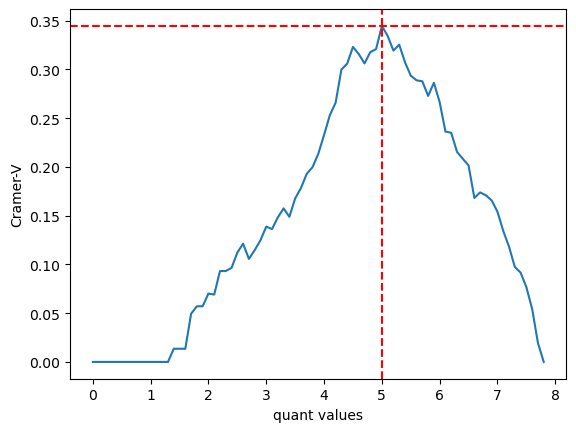

In [106]:
#прологарифмируем
max_cramerv_corr_finder(np.log(data['last_3_views']+1), data['is_bought']== 1, plot = True, print_inference = True, step = 0.1)

In [107]:
# преобразуем в исходную шкалу полученное рекомендованное значение
np.exp(5)-1

147.4131591025766

По историческим данным наилучшая корреляция достигается при 147+ уровне просмотров за 3 дня перед отправкой в архив

# Проверим, как ведет себя прокси метрика на АБ-тесте

### Запустим симуляцию

In [67]:
ab_binary_ztest_pvalue_list = []
ab_quant_ztest_pvalue_list = []
a_group_sample_size_prop_list = []
quant_target_level = 3
effect = 0.1
n_sim = 10000

for i in range(n_sim):
    sample_mask = ss.bernoulli.rvs(0.5, size=len(data)) == 1

    binary_mask_group_a = (data['is_bought']==1)[sample_mask]
    binary_mask_group_b = (data['is_bought']==1)[~sample_mask]
    quant_value_group_a = (data['last_3_contacts'])[sample_mask]
    quant_value_group_b = (data['last_3_contacts'])[~sample_mask]

    binary_nobs_group_a = len(binary_mask_group_a)
    binary_nobs_group_b = len(binary_mask_group_b)
    quant_nobs_group_a = len(quant_value_group_a)
    quant_nobs_group_b = len(quant_value_group_b)

    sample_size_prop = binary_nobs_group_a/len(data)
    a_group_sample_size_prop_list.append(sample_size_prop)

    binary_counts_group_a = binary_mask_group_a.sum()
    binary_counts_group_b = round(binary_mask_group_b.sum()*(1+effect)) #add effect
    quant_counts_group_a = (quant_value_group_a > quant_target_level).sum()
    quant_counts_group_b = round((quant_value_group_b > quant_target_level).sum()*(1+effect)) #add effect

    binary_z_score_i, binary_ztest_pvalue_i = sms.proportions_ztest(count = [binary_counts_group_a, binary_counts_group_b],
                          nobs = [binary_nobs_group_a, binary_nobs_group_b])

    quant_z_score_i, quant_ztest_pvalue_i = sms.proportions_ztest(count = [quant_counts_group_a, quant_counts_group_b],
                          nobs = [quant_nobs_group_a, quant_nobs_group_b])

    ab_binary_ztest_pvalue_list.append(binary_ztest_pvalue_i)
    ab_quant_ztest_pvalue_list.append(quant_ztest_pvalue_i)

binary_power_ci = proportion_confint((np.array(ab_binary_ztest_pvalue_list) <= 0.05).sum(), n_sim, alpha=0.01)
quant_power_ci = proportion_confint((np.array(ab_quant_ztest_pvalue_list) <= 0.05).sum(), n_sim, alpha=0.01)

print('Effect =', effect)
print('AVG sample size A group proportion =', np.mean(a_group_sample_size_prop_list))
print('AVG sample size A group =', round(np.mean(a_group_sample_size_prop_list)*len(data)))
print('AVG sample size B group =', round((1-np.mean(a_group_sample_size_prop_list))*len(data)))
print('------------------')
print('Target conversion A group = ', binary_counts_group_a / binary_nobs_group_a)
print('Target conversion B group = ', binary_counts_group_b / binary_nobs_group_b)
print('Proxy conversion A group = ', quant_counts_group_a / quant_nobs_group_a)
print('Proxy conversion B group = ', quant_counts_group_b / quant_nobs_group_b)
print('------------------')
print('Мощность АБ-теста по целевой метрике', (np.array(ab_binary_ztest_pvalue_list) <= 0.05).sum() / n_sim)
print('99%-процентный доверительный интервал для целевой метрики', binary_power_ci)
print('Мощность АБ-теста по прокси-метрике', (np.array(ab_quant_ztest_pvalue_list) <= 0.05).sum() / n_sim)
print('99%-процентный доверительный интервал для прокси-метрики', quant_power_ci)

Effect = 0.1
AVG sample size A group proportion = 0.4997647108130764
AVG sample size A group = 596
AVG sample size B group = 597
------------------
Target conversion A group =  0.31399317406143346
Target conversion B group =  0.40197693574958815
Proxy conversion A group =  0.4112627986348123
Proxy conversion B group =  0.46787479406919275
------------------
Мощность АБ-теста по целевой метрике 0.2445
99%-процентный доверительный интервал для целевой метрики (0.2334293340696393, 0.2555706659303607)
Мощность АБ-теста по прокси-метрике 0.3147
99%-процентный доверительный интервал для прокси-метрики (0.3027379443931156, 0.3266620556068844)


Mощность по прокси-метрике выше, так как прокси-метрика имеет более высокую конверсию, 
из-за этого по формуле расчета размера выборки при одинаковом количестве наблюдений она будет иметь большую мощность, чем меньшая целевая конверсия